Based on desi-photoz/dr9_desi/final_pz_performance-main_lrgs.ipynb and final_pz_performance-south.ipynb

In [1]:
import sys, os, warnings, gc, time, glob, argparse
from pathlib import Path
from multiprocessing import Pool

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, hstack
import fitsio

sys.path.append(os.path.expanduser('~/git/desi-photoz/'))
import pz_modules

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

----------
# Main LRGs

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/dr9_desi/rf/final_pz/main/main-lrg-daily-thru20210615-add_pz_new.fits'))
print(len(cat))

291793


86880 204913


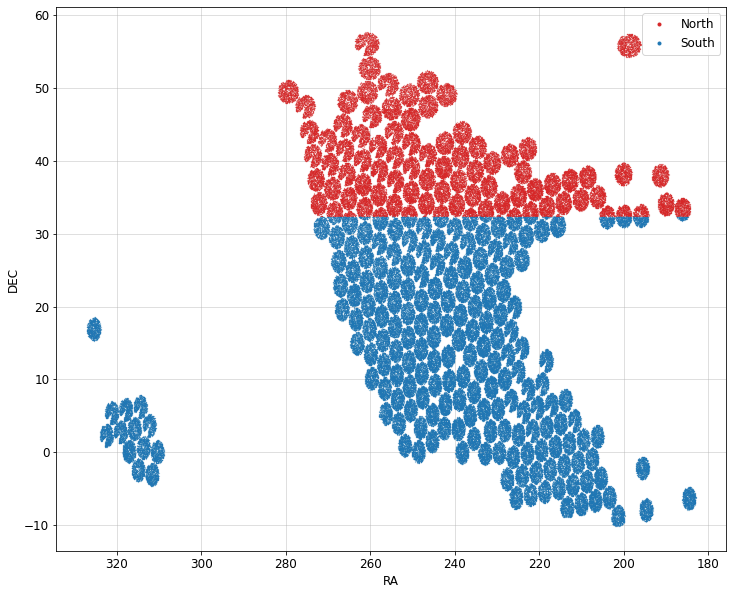

In [4]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

plt.figure(figsize=(12, 10))
plt.plot(cat['TARGET_RA'][mask_north], cat['TARGET_DEC'][mask_north], 'C3.', ms=.3, label='North')
plt.plot(cat['TARGET_RA'][mask_south], cat['TARGET_DEC'][mask_south], 'C0.', ms=.3, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 950.
mask = cat['COADD_EFFTIME_GFA']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Remove not-done fibers
# mask = cat['ZDONE']==1
# cat = cat[mask]
# print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    3475 288318 0.011909127360834564
No data    0 288318 0.0
Min depth    13737 274581 0.047645308305412776


In [6]:
# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Julien's bad fibers list
# bad_fibers = np.array(Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2680+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers), 'bad fibers')
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

Remove QSO targets 270105 4476 0.016301200738579873
205 bad fibers
Bad fibers 259340 10765 0.039854871253771684


In [7]:
# WISE and MEDIUM masks
maskbits = [8, 9, 11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
cat = cat[mask_clean]

MASKBITS 239627 19713 0.923987815223259


In [8]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

cat = cat[mask_quality]
print(len(cat))

0.018850129576383295
235110


In [9]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

z_phot = cat['Z_PHOT_MEDIAN']
z_spec = cat['Z']

72597 162513


Normalized MAD: 0.025112
0.10 outliers: 2.391193%


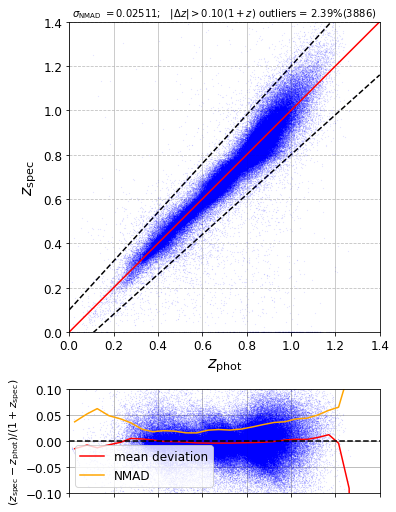

In [11]:
mask = mask_south.copy()
pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=0.4, zmin=0.0, zmax=1.4, verbose=False,
                 rasterized=True, show=False, figsize=(5.5, 7.17), pz_vs_sz=False)
plt.savefig('figures/sz_vs_pz_main_south.pdf')
plt.show()

Normalized MAD: 0.026556
0.10 outliers: 2.429852%


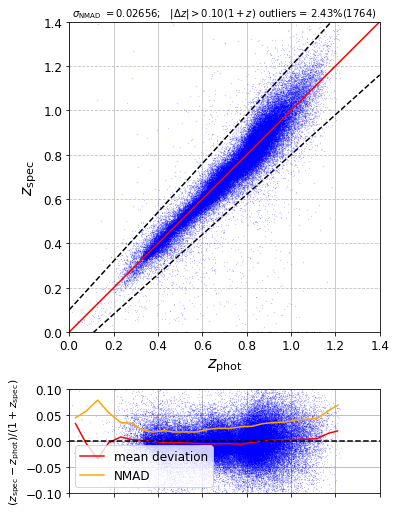

In [12]:
mask = mask_north.copy()
pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=0.4, alpha=0.4, zmin=0.0, zmax=1.4, verbose=False,
                 rasterized=True, show=False, figsize=(5.5, 7.17), pz_vs_sz=False)
plt.savefig('figures/sz_vs_pz_main_north.pdf')
plt.show()

----------------
# SV1 LRGs

__South__

In [13]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/dr9_desi/rf/final_pz_specz_combined_south.fits'))
print(len(cat))

mask = cat['Z_PHOT_MEDIAN']!=-99
print(np.sum(~mask))
cat = cat[mask]

z_phot = cat['Z_PHOT_MEDIAN']
z_spec = cat['Z_SPEC']

2451597
107


13090
Normalized MAD: 0.028952
0.10 outliers: 3.712758%


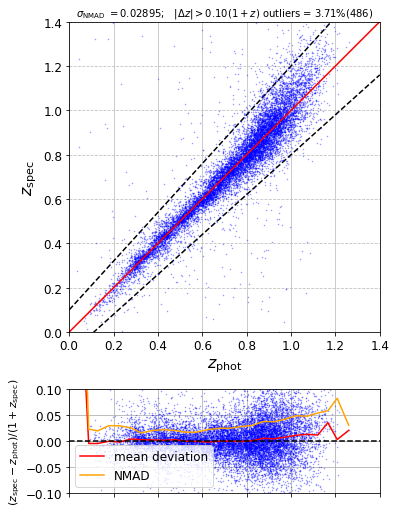

In [14]:
sv1_lrg = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/dr9_desi/rf/final_pz/sv1/denali_bgs_lrg_photo-z_added-20210715.fits', columns=['TARGETID', 'TARGETS']))
sv1_lrg = sv1_lrg[sv1_lrg['TARGETS']=='QSO+LRG']
mask = cat['SURVEY']=='DESI'
mask &= np.in1d(cat['TARGETID'], sv1_lrg['TARGETID'])
print(np.sum(mask))

pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=1, alpha=0.4, zmin=0.0, zmax=1.4, verbose=False,
                 rasterized=True, show=False, figsize=(5.5, 7.17), pz_vs_sz=False)
plt.savefig('figures/sz_vs_pz_sv1_south.pdf')
plt.show()

__North__

In [15]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/dr9_desi/rf/final_pz_specz_combined_north.fits'))
print(len(cat))

mask = cat['Z_PHOT_MEDIAN']!=-99
print(np.sum(~mask))
cat = cat[mask]

z_phot = cat['Z_PHOT_MEDIAN']
z_spec = cat['Z_SPEC']

1009018
76


12536
Normalized MAD: 0.033233
0.10 outliers: 4.810147%


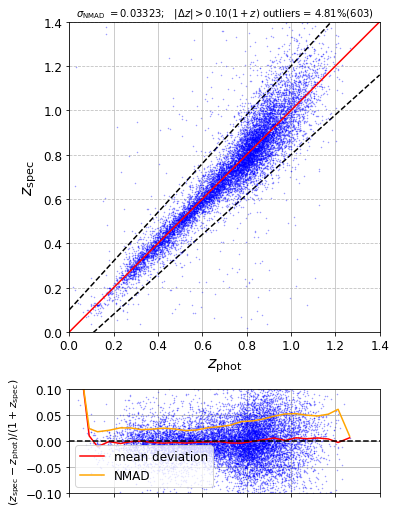

In [16]:
sv1_lrg = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_photoz/dr9_desi/rf/final_pz/sv1/denali_bgs_lrg_photo-z_added-20210715.fits', columns=['TARGETID', 'TARGETS']))
sv1_lrg = sv1_lrg[sv1_lrg['TARGETS']=='QSO+LRG']
mask = cat['SURVEY']=='DESI'
mask &= np.in1d(cat['TARGETID'], sv1_lrg['TARGETID'])
print(np.sum(mask))

pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=1, alpha=0.4, zmin=0.0, zmax=1.4, verbose=False,
                 rasterized=True, show=False, figsize=(5.5, 7.17), pz_vs_sz=False)
plt.savefig('figures/sz_vs_pz_sv1_north.pdf')
plt.show()